In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.io import fits
import glob, re

from limTOD import generate_TOD_sky, generate_LSTs_deg
from limTOD import GDSM_sky_model


Running: fixed


100%|██████████| 72/72 [00:04<00:00, 15.67it/s]


Reference freq: 70.00 MHz


100%|██████████| 72/72 [00:03<00:00, 20.86it/s]



Running: stepped


...

100%|██████████| 72/72 [00:03<00:00, 22.00it/s]



Running: continuous


100%|██████████| 72/72 [00:03<00:00, 19.81it/s]


Reference freq: 70.00 MHz


100%|██████████| 72/72 [00:03<00:00, 19.31it/s]


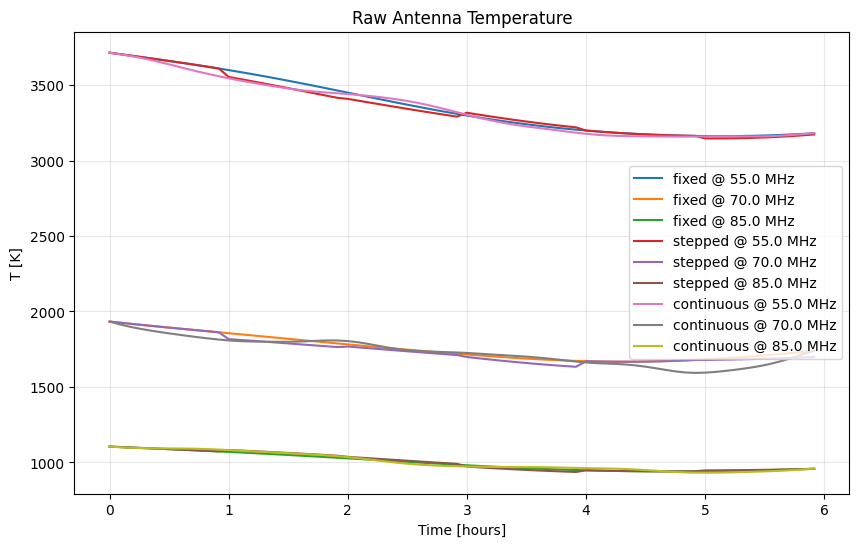

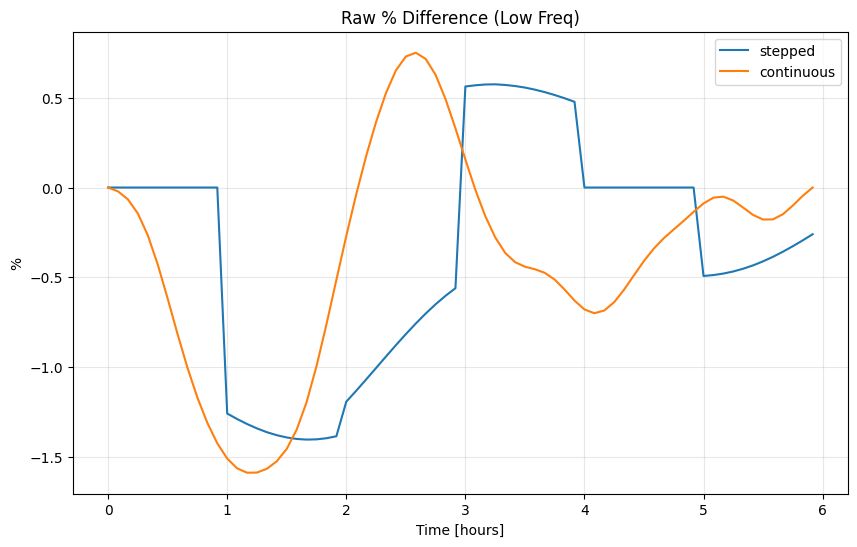

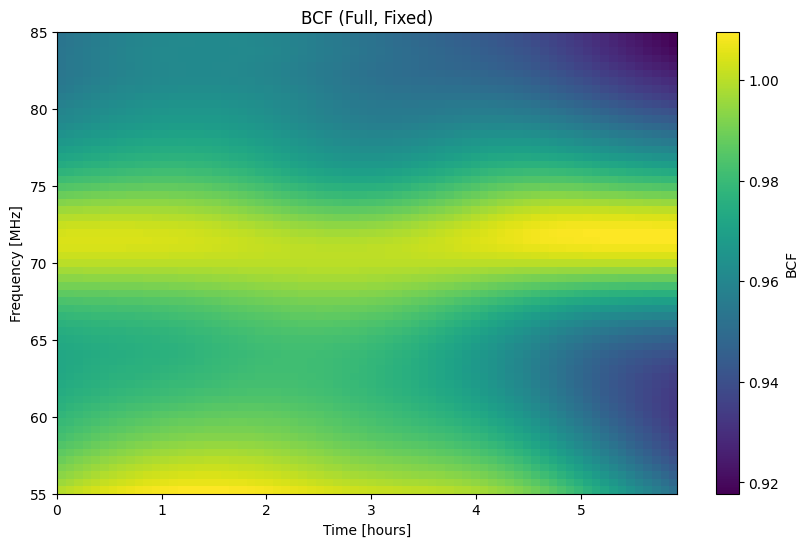

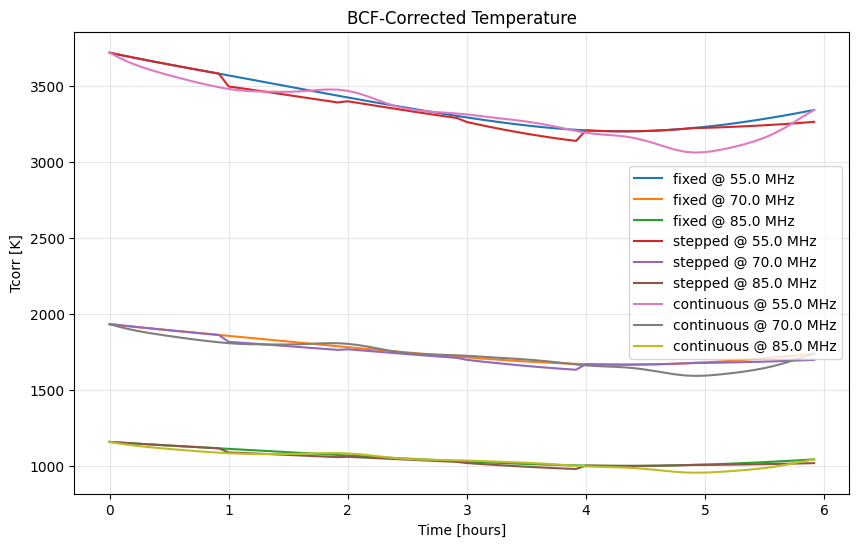

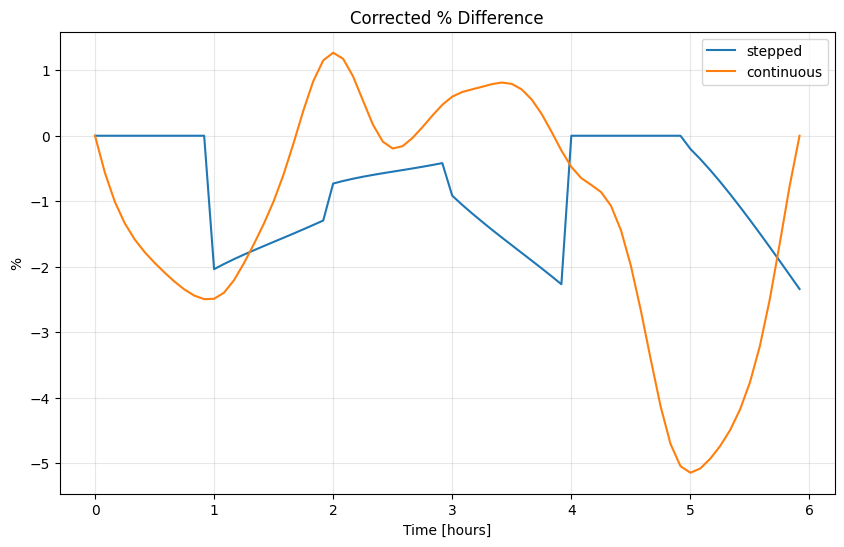

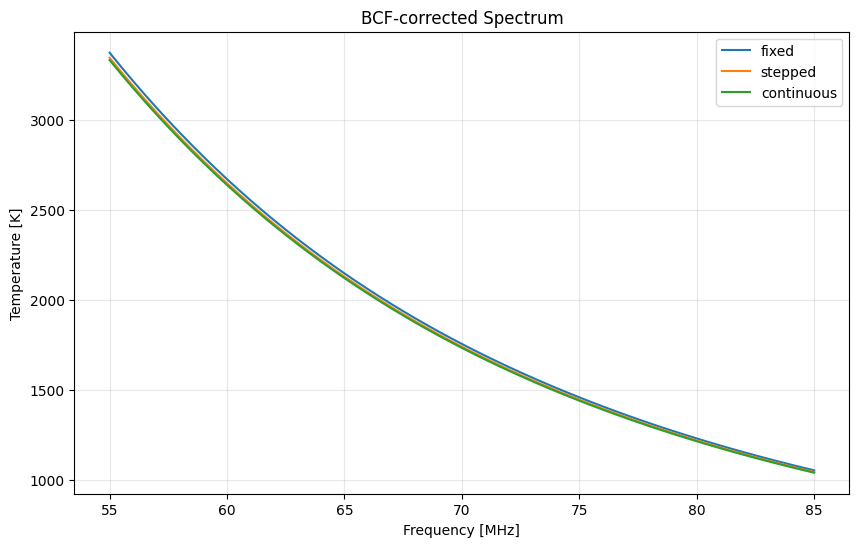

In [2]:
# ============================================================
# CONFIG
# ============================================================

BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 100

START_TIME = "2026-04-01 20:41:56.397"

DT = 300
N_TIME = int((6 * 3600) / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600

BEAM_NSIDE = 512
SKY_NSIDE = 64
NSIDE_HIRES = 128

# ============================================================
# LOAD BEAMS (NO NORMALIZATION)
# ============================================================

beam_files = sorted(glob.glob(BEAM_GLOB))
beam_dict = {}

for f in beam_files:
    freq = float(re.search(r"(\d+\.\d+)", f).group(1))

    with fits.open(f) as hdul:
        beam = np.array(hdul[1].data.field(0)).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0

    # IMPORTANT: NO NORMALIZATION HERE
    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))

def beam_func(freq, nside):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near]

    if hp.npix2nside(len(beam)) != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)

    return beam  # not normalized

# ============================================================
# SKY + LST
# ============================================================

LST_deg = generate_LSTs_deg(
    ANT_LAT, ANT_LON, ANT_H,
    time_list,
    start_time_utc=START_TIME
)

az_list = np.zeros(N_TIME)
el_list = np.full(N_TIME, 90.0)

# ============================================================
# ROTATION MODES
# ============================================================

sr_fixed = np.zeros(N_TIME)

sr_step = np.zeros(N_TIME)
step_deg = [0, 45, 90, 135]
for i in range(N_TIME):
    sr_step[i] = step_deg[(i // (3600 // DT)) % len(step_deg)]

sr_cont = (time_list / time_list[-1]) * 360

rotation_cases = {
    "fixed": sr_fixed,
    "stepped": sr_step,
    "continuous": sr_cont
}

# ============================================================
# ANTENNA TEMPERATURE
# ============================================================

def compute_T(sr_list):

    T = np.zeros((len(freq_list), N_TIME))

    for i, nu in enumerate(freq_list):

        beam = beam_func(nu, BEAM_NSIDE)
        sky = GDSM_sky_model(freq=nu, nside=SKY_NSIDE)

        T[i] = generate_TOD_sky(
            beam, sky,
            LST_deg, ANT_LAT,
            az_list, el_list, sr_list,
            nside_hires=NSIDE_HIRES,
            normalize_beam=True   # keep this TRUE
        )

    return T

# ============================================================
# FULL BCF (NO SIMPLIFICATION)
# ============================================================

def compute_BCF_full(sr_list, nu_ref=70.0):

    nu_ref_idx = np.argmin(np.abs(freq_list - nu_ref))
    nu_ref_actual = freq_list[nu_ref_idx]

    print(f"Reference freq: {nu_ref_actual:.2f} MHz")

    # reference sky
    sky_ref = GDSM_sky_model(freq=nu_ref_actual, nside=SKY_NSIDE)

    # reference beam
    beam_ref = beam_func(nu_ref_actual, BEAM_NSIDE)

    # sky-weighted denominator
    T_ref = generate_TOD_sky(
        beam_ref, sky_ref,
        LST_deg, ANT_LAT,
        az_list, el_list, sr_list,
        nside_hires=NSIDE_HIRES,
        normalize_beam=True
    )

    # beam integral at reference
    beam_ref_int = np.sum(beam_ref)

    BCF = np.zeros((len(freq_list), N_TIME))

    for i, nu in enumerate(freq_list):

        beam = beam_func(nu, BEAM_NSIDE)

        # numerator
        T_num = generate_TOD_sky(
            beam, sky_ref,
            LST_deg, ANT_LAT,
            az_list, el_list, sr_list,
            nside_hires=NSIDE_HIRES,
            normalize_beam=True
        )

        # beam integral
        beam_int = np.sum(beam)

        # FULL BCF (paper equation)
        BCF[i] = (T_num / T_ref) * (beam_ref_int / beam_int)

    return BCF

# ============================================================
# RUN SIMULATION
# ============================================================

results = {}
bcf_results = {}
Tcorr_results = {}

for name, sr in rotation_cases.items():

    print("\nRunning:", name)

    T = compute_T(sr)
    BCF = compute_BCF_full(sr)

    results[name] = T
    bcf_results[name] = BCF

    # Apply correction
    Tcorr_results[name] = T / BCF

# ============================================================
# PLOT 1 — RAW ANTENNA TEMP
# ============================================================

plt.figure(figsize=(10,6))

freq_indices = [0, len(freq_list)//2, -1]

for name, T in results.items():
    for idx in freq_indices:
        plt.plot(time_hours, T[idx],
                 label=f"{name} @ {freq_list[idx]:.1f} MHz")

plt.title("Raw Antenna Temperature")
plt.xlabel("Time [hours]")
plt.ylabel("T [K]")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOT 2 — RAW DIFFERENCE
# ============================================================

plt.figure(figsize=(10,6))

T_ref = results["fixed"]

for name in ["stepped", "continuous"]:
    diff = (results[name] - T_ref) / T_ref * 100
    plt.plot(time_hours, diff[0], label=name)

plt.title("Raw % Difference (Low Freq)")
plt.xlabel("Time [hours]")
plt.ylabel("%")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOT 3 — BCF WATERFALL
# ============================================================

plt.figure(figsize=(10,6))

plt.imshow(
    bcf_results["fixed"],
    aspect="auto",
    origin="lower",
    extent=[time_hours[0], time_hours[-1],
            freq_list[0], freq_list[-1]]
)

plt.colorbar(label="BCF")
plt.xlabel("Time [hours]")
plt.ylabel("Frequency [MHz]")
plt.title("BCF (Full, Fixed)")
plt.show()

# ============================================================
# PLOT 4 — CORRECTED T
# ============================================================

plt.figure(figsize=(10,6))

for name, Tcorr in Tcorr_results.items():
    for idx in freq_indices:
        plt.plot(time_hours, Tcorr[idx],
                 label=f"{name} @ {freq_list[idx]:.1f} MHz")

plt.title("BCF-Corrected Temperature")
plt.xlabel("Time [hours]")
plt.ylabel("Tcorr [K]")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOT 5 — CORRECTED DIFFERENCE
# ============================================================

plt.figure(figsize=(10,6))

Tcorr_ref = Tcorr_results["fixed"]

for name in ["stepped", "continuous"]:
    diff = (Tcorr_results[name] - Tcorr_ref) / Tcorr_ref * 100
    plt.plot(time_hours, diff[0], label=name)

plt.title("Corrected % Difference")
plt.xlabel("Time [hours]")
plt.ylabel("%")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOT 6 — SPECTRUM (PDF requirement)
# ============================================================

plt.figure(figsize=(10,6))

for name, Tcorr in Tcorr_results.items():
    mean_spec = np.mean(Tcorr, axis=1)
    plt.plot(freq_list, mean_spec, label=name)

plt.title("BCF-corrected Spectrum")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Temperature [K]")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Running tilt = 90.0 deg


100%|██████████| 72/72 [00:05<00:00, 13.16it/s]


Reference freq: 70.00 MHz


100%|██████████| 72/72 [00:03<00:00, 23.32it/s]



Running tilt = 75.0 deg


...

100%|██████████| 72/72 [00:03<00:00, 23.67it/s]



Running tilt = 60.0 deg


100%|██████████| 72/72 [00:03<00:00, 23.37it/s]


Reference freq: 70.00 MHz


100%|██████████| 72/72 [00:03<00:00, 22.69it/s]


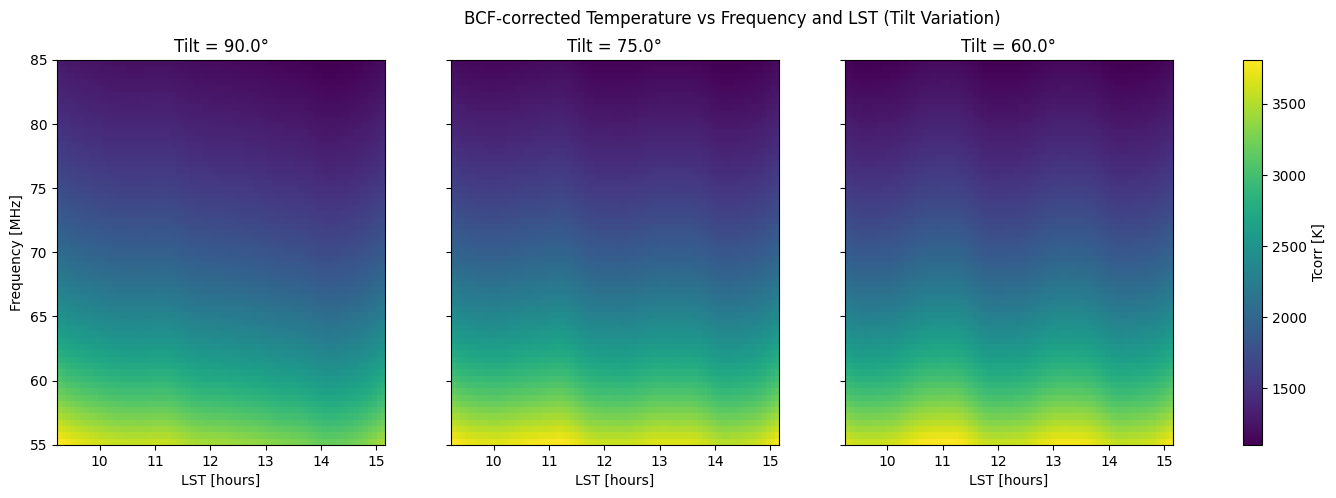

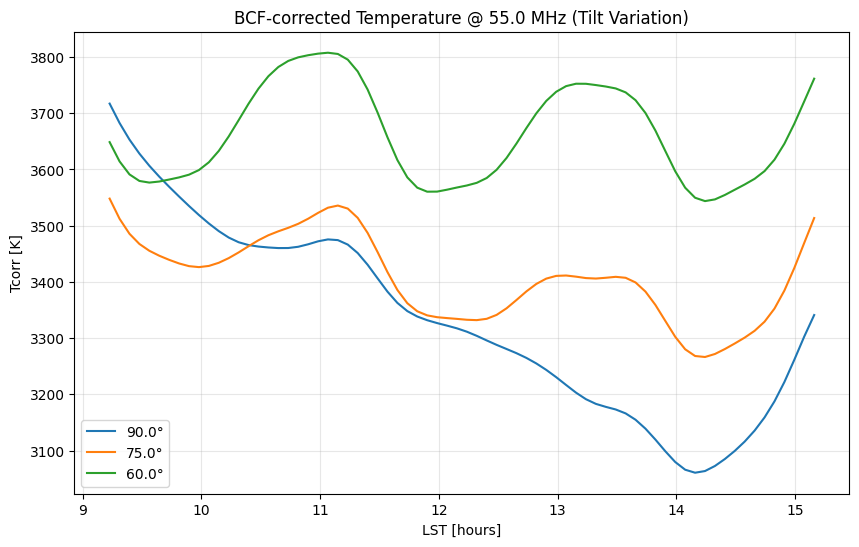

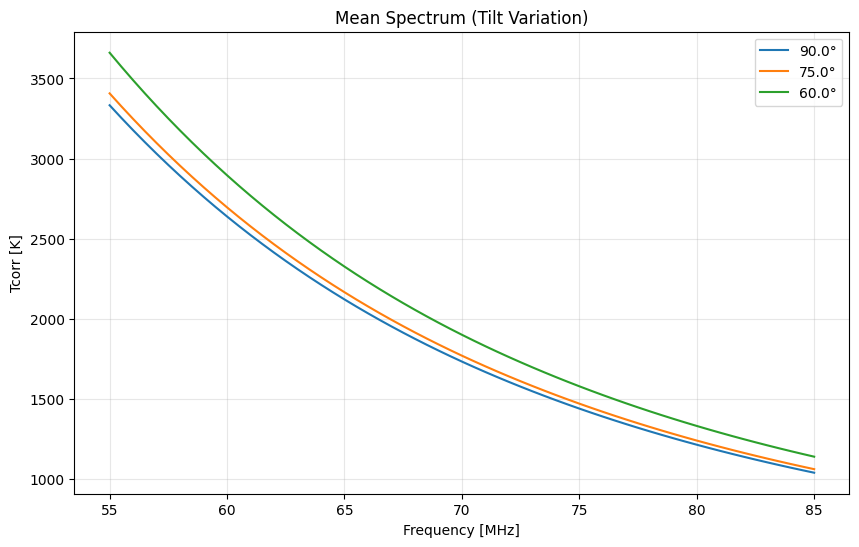

In [4]:

# # ============================================================
# # CONFIG
# # ============================================================

# BEAM_GLOB = "../data/HornWet/HornWet*.fits"

# ANT_LAT = 53.2421
# ANT_LON = -2.3067
# ANT_H   = 100

# START_TIME = "2026-04-01 20:41:56.397"

# DT = 300
# N_TIME = int((6 * 3600) / DT)

# time_list = np.arange(N_TIME) * DT
# time_hours = time_list / 3600

# BEAM_NSIDE = 512
# SKY_NSIDE = 64
# NSIDE_HIRES = 128

# # ============================================================
# # LOAD BEAMS
# # ============================================================

# beam_files = sorted(glob.glob(BEAM_GLOB))
# beam_dict = {}

# for f in beam_files:
#     freq = float(re.search(r"(\d+\.\d+)", f).group(1))

#     with fits.open(f) as hdul:
#         beam = np.array(hdul[1].data.field(0)).reshape(-1)

#     beam = np.nan_to_num(beam)
#     beam[beam < 0] = 0
#     beam /= np.sum(beam)

#     beam_dict[freq] = beam

# freq_list = np.array(sorted(beam_dict.keys()))

# def beam_func(freq, nside):
#     f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
#     beam = beam_dict[f_near]

#     if hp.npix2nside(len(beam)) != nside:
#         beam = hp.ud_grade(beam, nside_out=nside, power=-2)

#     return beam / np.sum(beam)

# # ============================================================
# # SKY + LST
# # ============================================================

# LST_deg = generate_LSTs_deg(
#     ANT_LAT, ANT_LON, ANT_H,
#     time_list,
#     start_time_utc=START_TIME
# )

# LST_hours = LST_deg / 15.0

# az_list = np.zeros(N_TIME)

# ============================================================
# CONTINUOUS ROTATION
# ============================================================

sr_cont = (time_list / time_list[-1]) * 360

# ============================================================
# TILT CASES (NEW)
# ============================================================

tilt_angles = [90.0, 75.0, 60.0]  # degrees

# ============================================================
# ANTENNA TEMPERATURE
# ============================================================

def compute_T(sr_list, el_list):
    T = np.zeros((len(freq_list), N_TIME))

    for i, nu in enumerate(freq_list):

        beam = beam_func(nu, BEAM_NSIDE)
        sky = GDSM_sky_model(freq=nu, nside=SKY_NSIDE)

        T[i] = generate_TOD_sky(
            beam, sky,
            LST_deg, ANT_LAT,
            az_list, el_list, sr_list,
            nside_hires=NSIDE_HIRES,
            normalize_beam=True
        )

    return T

# ============================================================
# BCF
# ============================================================

def compute_BCF(sr_list, el_list, nu_ref=70.0):

    nu_ref_idx = np.argmin(np.abs(freq_list - nu_ref))
    nu_ref_actual = freq_list[nu_ref_idx]

    print(f"Reference freq: {nu_ref_actual:.2f} MHz")

    sky_ref = GDSM_sky_model(freq=nu_ref_actual, nside=SKY_NSIDE)
    beam_ref = beam_func(nu_ref_actual, BEAM_NSIDE)

    T_ref = generate_TOD_sky(
        beam_ref, sky_ref,
        LST_deg, ANT_LAT,
        az_list, el_list, sr_list,
        nside_hires=NSIDE_HIRES,
        normalize_beam=True
    )

    BCF = np.zeros((len(freq_list), N_TIME))

    for i, nu in enumerate(freq_list):

        beam = beam_func(nu, BEAM_NSIDE)

        T_num = generate_TOD_sky(
            beam, sky_ref,
            LST_deg, ANT_LAT,
            az_list, el_list, sr_list,
            nside_hires=NSIDE_HIRES,
            normalize_beam=True
        )

        BCF[i] = T_num / T_ref

    return BCF

# ============================================================
# RUN FOR ALL TILTS
# ============================================================

results = {}
bcf_results = {}
Tcorr_results = {}

for el in tilt_angles:

    print(f"\nRunning tilt = {el} deg")

    el_list = np.full(N_TIME, el)

    T = compute_T(sr_cont, el_list)
    BCF = compute_BCF(sr_cont, el_list)

    results[el] = T
    bcf_results[el] = BCF
    Tcorr_results[el] = T / BCF

# ============================================================
# PLOT 1 — Tcorr(freq, LST) FOR EACH TILT
# ============================================================

fig, axes = plt.subplots(1, len(tilt_angles), figsize=(18,5), sharey=True)

for ax, el in zip(axes, tilt_angles):

    Tcorr = Tcorr_results[el]

    im = ax.imshow(
        Tcorr,
        aspect="auto",
        origin="lower",
        extent=[LST_hours[0], LST_hours[-1],
                freq_list[0], freq_list[-1]]
    )

    ax.set_title(f"Tilt = {el}°")
    ax.set_xlabel("LST [hours]")

axes[0].set_ylabel("Frequency [MHz]")
fig.colorbar(im, ax=axes, label="Tcorr [K]")

plt.suptitle("BCF-corrected Temperature vs Frequency and LST (Tilt Variation)")
plt.show()

# ============================================================
# PLOT 2 — TIME SERIES (LOW FREQ)
# ============================================================

low_idx = 0

plt.figure(figsize=(10,6))

for el in tilt_angles:
    plt.plot(LST_hours, Tcorr_results[el][low_idx], label=f"{el}°")

plt.xlabel("LST [hours]")
plt.ylabel("Tcorr [K]")
plt.title(f"BCF-corrected Temperature @ {freq_list[low_idx]:.1f} MHz (Tilt Variation)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOT 3 — MEAN SPECTRUM
# ============================================================

plt.figure(figsize=(10,6))

for el in tilt_angles:
    mean_spec = np.mean(Tcorr_results[el], axis=1)
    plt.plot(freq_list, mean_spec, label=f"{el}°")

plt.xlabel("Frequency [MHz]")
plt.ylabel("Tcorr [K]")
plt.title("Mean Spectrum (Tilt Variation)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Beam Variation


Running blade_scale=0.8, tilt=90.0 deg


100%|██████████| 72/72 [00:03<00:00, 22.80it/s]


Using reference frequency: 70.00 MHz


100%|██████████| 72/72 [00:03<00:00, 23.74it/s]



Running blade_scale=0.8, tilt=75.0 deg


...

100%|██████████| 72/72 [00:03<00:00, 18.25it/s]



Running blade_scale=1.2, tilt=60.0 deg


100%|██████████| 72/72 [00:03<00:00, 23.35it/s]


Using reference frequency: 70.00 MHz


100%|██████████| 72/72 [00:03<00:00, 23.67it/s]
/var/folders/y0/4z9tprvs2qb6qwgklyjc_tbw0000gp/T/ipykernel_22292/957123110.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


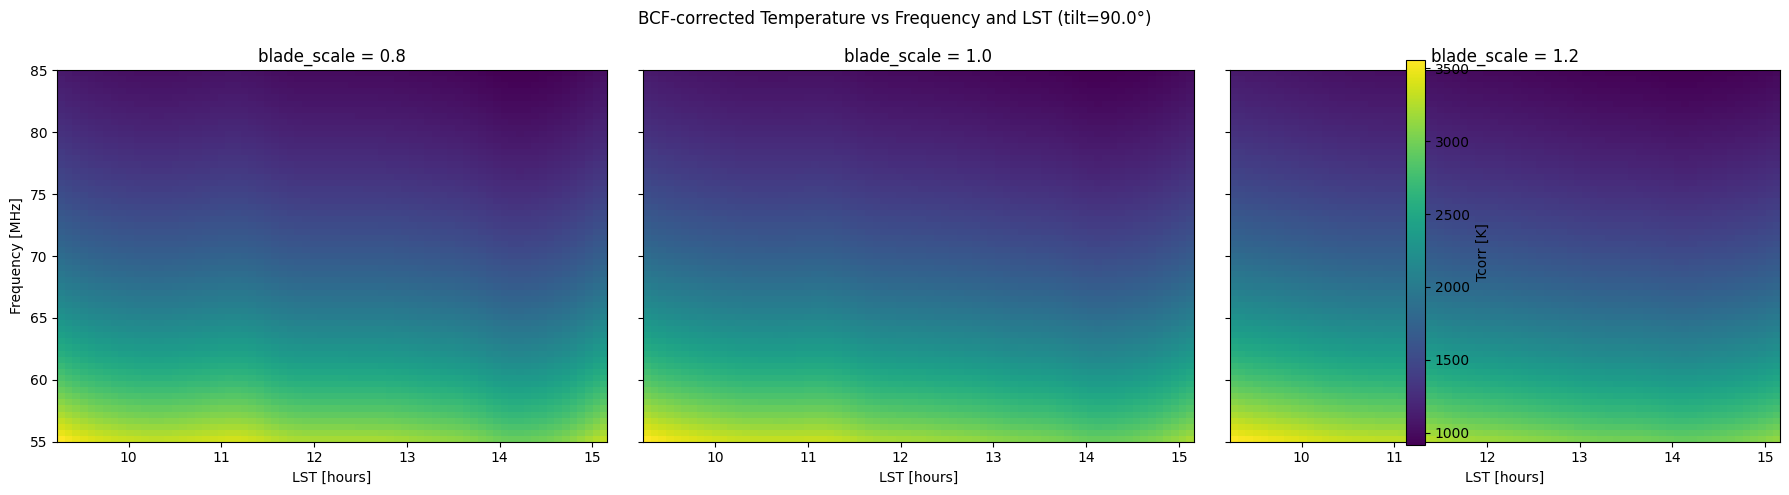

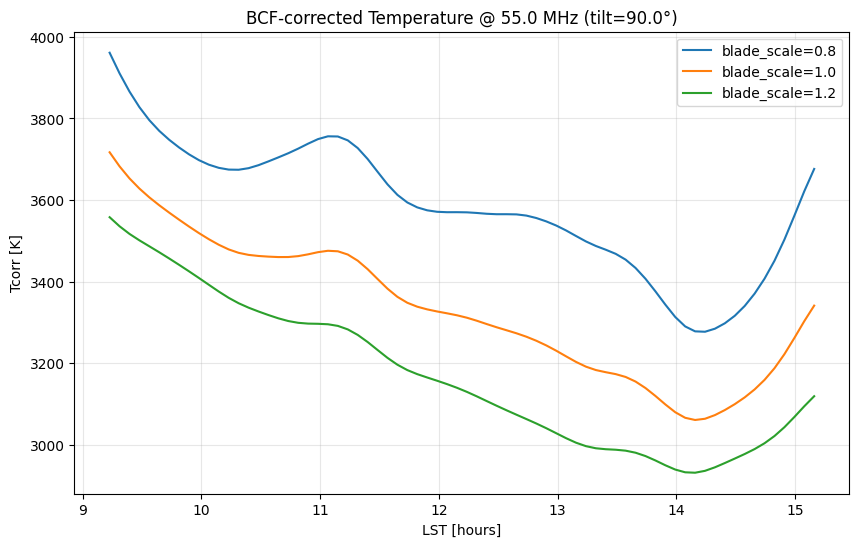

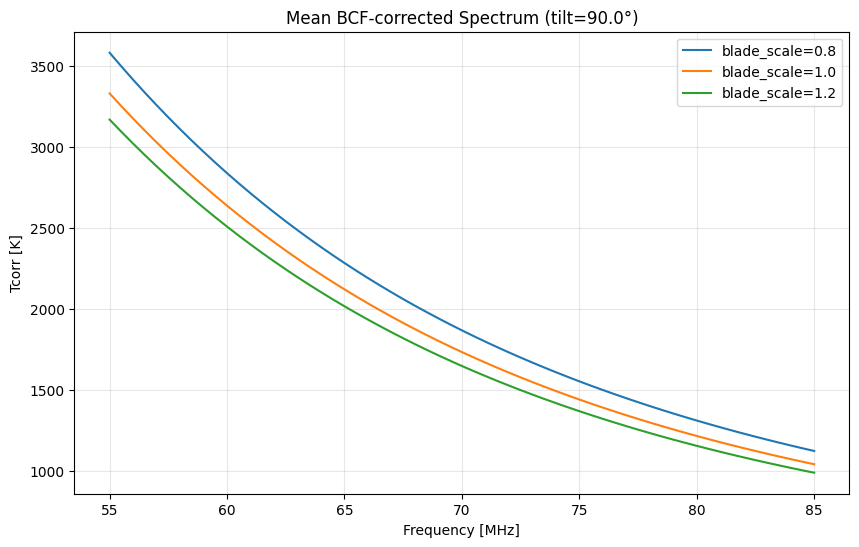

/var/folders/y0/4z9tprvs2qb6qwgklyjc_tbw0000gp/T/ipykernel_22292/957123110.py:309: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


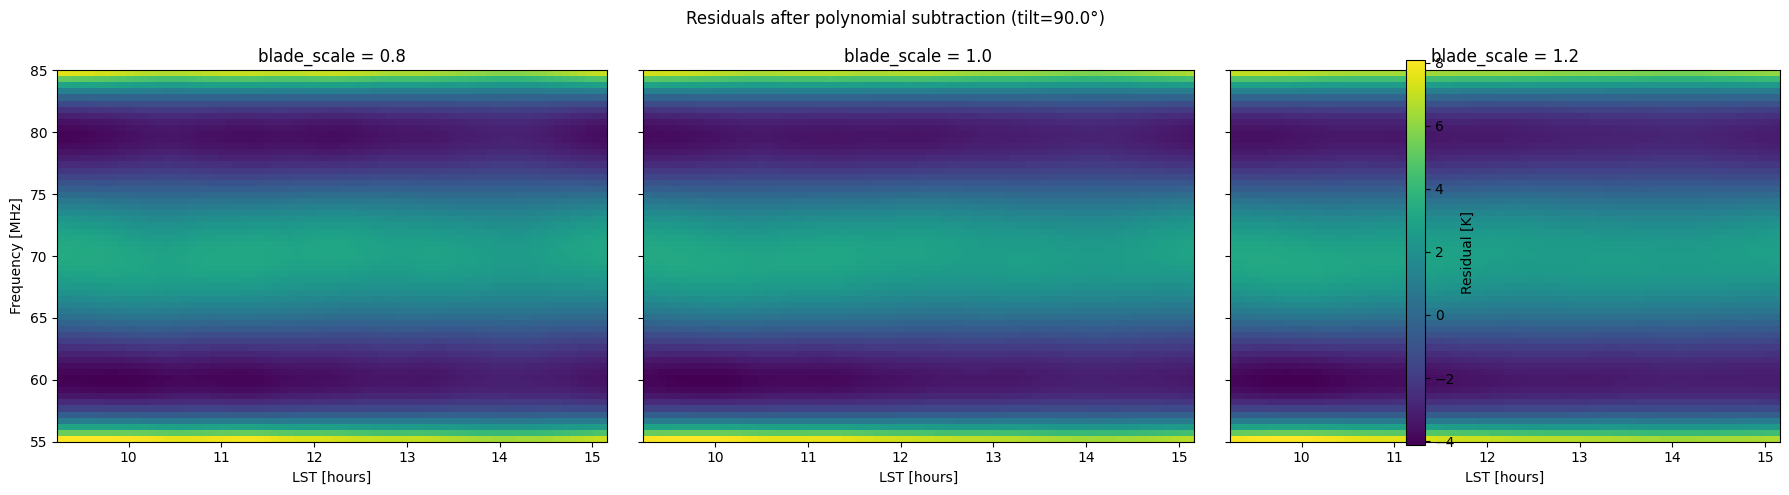

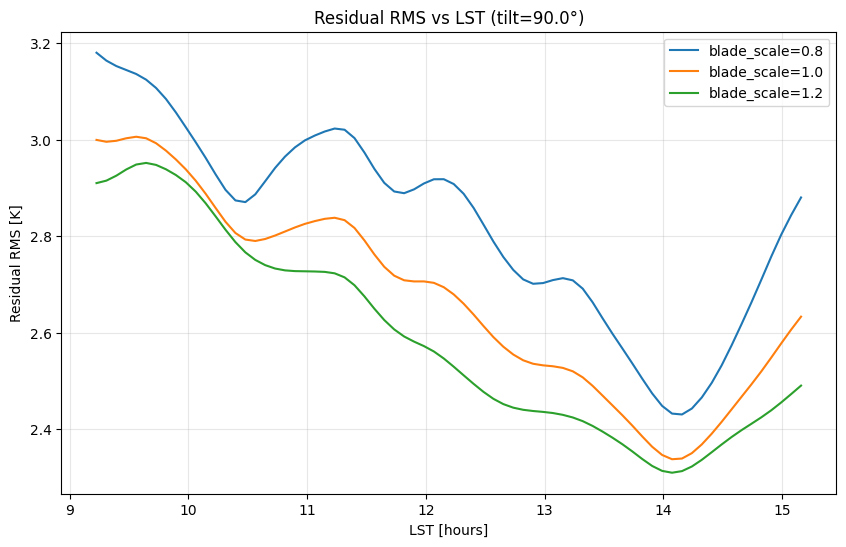

/var/folders/y0/4z9tprvs2qb6qwgklyjc_tbw0000gp/T/ipykernel_22292/957123110.py:354: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


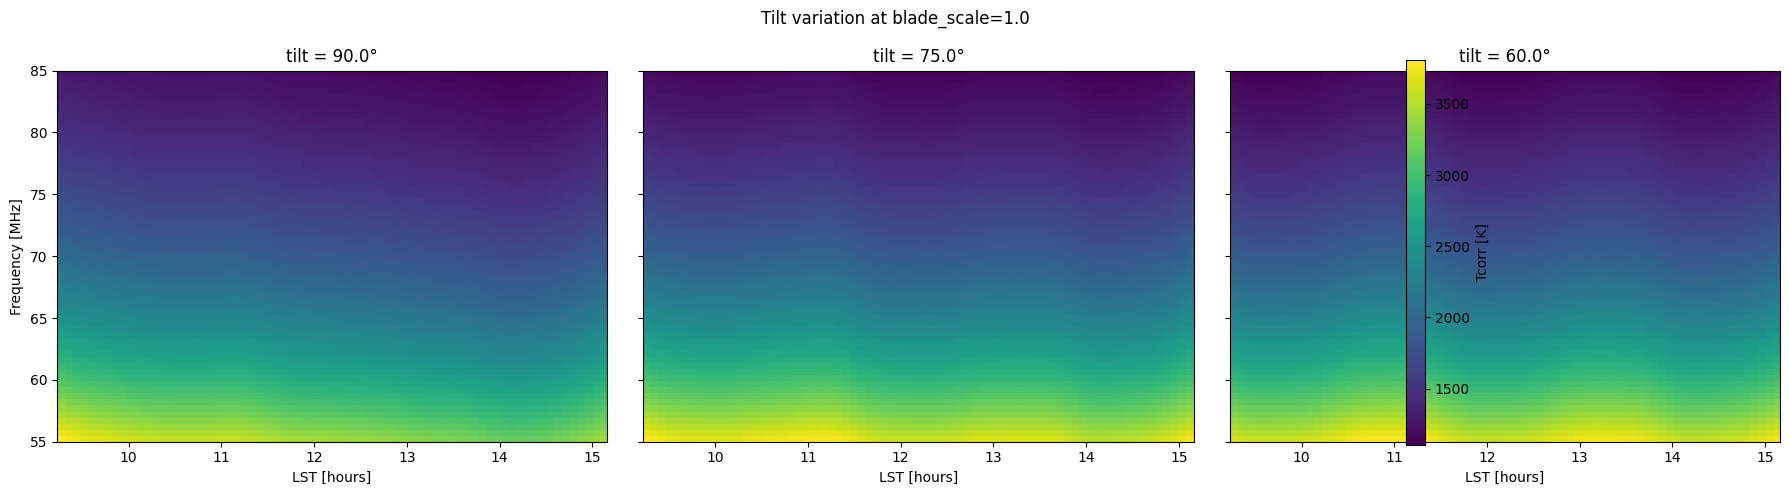

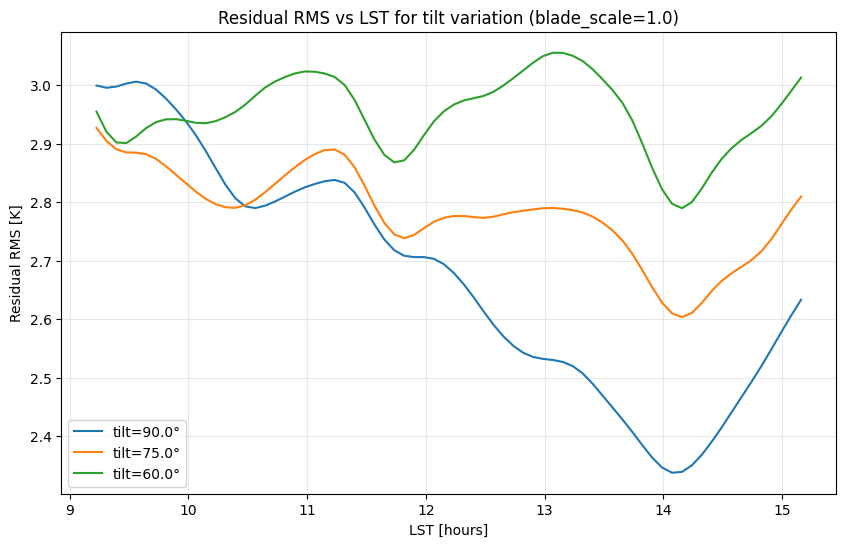

In [5]:

# ============================================================
# CONFIG
# ============================================================

BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 100

START_TIME = "2026-04-01 20:41:56.397"

DT = 300
N_TIME = int((6 * 3600) / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600

BEAM_NSIDE = 512
SKY_NSIDE = 64
NSIDE_HIRES = 128

# ============================================================
# LOAD BEAMS
# ============================================================

beam_files = sorted(glob.glob(BEAM_GLOB))
beam_dict = {}

for f in beam_files:
    freq = float(re.search(r"(\d+\.\d+)", f).group(1))

    with fits.open(f) as hdul:
        beam = np.array(hdul[1].data.field(0)).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0
    beam /= np.sum(beam)

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))

# ============================================================
# BEAM FUNCTION WITH "BLADE SEPARATION" PROXY
# ============================================================

def beam_func(freq, nside, blade_scale=1.0):
    """
    blade_scale is a proxy for blade separation:
      blade_scale < 1.0  -> broader beam  -> smaller effective separation
      blade_scale = 1.0  -> original beam
      blade_scale > 1.0  -> narrower beam -> larger effective separation
    """
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near].copy()

    if hp.npix2nside(len(beam)) != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)

    # Proxy for beam-width change
    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0
    beam = beam ** blade_scale

    # keep normalized for current BCF pipeline
    beam_sum = np.sum(beam)
    if beam_sum > 0:
        beam /= beam_sum

    return beam

# ============================================================
# SKY + LST
# ============================================================

LST_deg = generate_LSTs_deg(
    ANT_LAT, ANT_LON, ANT_H,
    time_list,
    start_time_utc=START_TIME
)

LST_hours = LST_deg / 15.0

az_list = np.zeros(N_TIME)

# ============================================================
# CONTINUOUS SELF ROTATION
# ============================================================

sr_cont = (time_list / time_list[-1]) * 360.0

# ============================================================
# TILT CASES
# ============================================================

tilt_angles = [90.0, 75.0, 60.0]

# ============================================================
# "BLADE SEPARATION" CASES
# ============================================================

blade_scales = [0.8, 1.0, 1.2]

# ============================================================
# ANTENNA TEMPERATURE
# ============================================================

def compute_T(sr_list, el_list, blade_scale):
    T = np.zeros((len(freq_list), N_TIME))

    for i, nu in enumerate(freq_list):
        beam = beam_func(nu, BEAM_NSIDE, blade_scale=blade_scale)
        sky = GDSM_sky_model(freq=nu, nside=SKY_NSIDE)

        T[i] = generate_TOD_sky(
            beam, sky,
            LST_deg, ANT_LAT,
            az_list, el_list, sr_list,
            nside_hires=NSIDE_HIRES,
            normalize_beam=True
        )

    return T

# ============================================================
# BCF
# ============================================================

def compute_BCF(sr_list, el_list, blade_scale, nu_ref=70.0):
    nu_ref_idx = np.argmin(np.abs(freq_list - nu_ref))
    nu_ref_actual = freq_list[nu_ref_idx]

    print(f"Using reference frequency: {nu_ref_actual:.2f} MHz")

    sky_ref = GDSM_sky_model(freq=nu_ref_actual, nside=SKY_NSIDE)
    beam_ref = beam_func(nu_ref_actual, BEAM_NSIDE, blade_scale=blade_scale)

    T_ref = generate_TOD_sky(
        beam_ref, sky_ref,
        LST_deg, ANT_LAT,
        az_list, el_list, sr_list,
        nside_hires=NSIDE_HIRES,
        normalize_beam=True
    )

    BCF = np.zeros((len(freq_list), N_TIME))

    for i, nu in enumerate(freq_list):
        beam = beam_func(nu, BEAM_NSIDE, blade_scale=blade_scale)

        T_num = generate_TOD_sky(
            beam, sky_ref,
            LST_deg, ANT_LAT,
            az_list, el_list, sr_list,
            nside_hires=NSIDE_HIRES,
            normalize_beam=True
        )

        BCF[i] = T_num / T_ref

    return BCF

# ============================================================
# POLY FIT + RESIDUALS
# ============================================================

def fit_and_subtract_poly(freq, spectrum, order=3):
    coeffs = np.polyfit(freq, spectrum, order)
    model = np.polyval(coeffs, freq)
    residual = spectrum - model
    return residual, model

def compute_residuals(Tcorr, freq_list, order=3):
    n_freq, n_time = Tcorr.shape
    residuals = np.zeros_like(Tcorr)

    for t in range(n_time):
        spec = Tcorr[:, t]
        res, _ = fit_and_subtract_poly(freq_list, spec, order=order)
        residuals[:, t] = res

    return residuals

def compute_rms_over_freq(residuals):
    return np.sqrt(np.mean(residuals**2, axis=0))

# ============================================================
# RUN ALL CASES
# ============================================================

results = {}
bcf_results = {}
Tcorr_results = {}
residual_results = {}

for blade_scale in blade_scales:
    results[blade_scale] = {}
    bcf_results[blade_scale] = {}
    Tcorr_results[blade_scale] = {}
    residual_results[blade_scale] = {}

    for el in tilt_angles:
        print(f"\nRunning blade_scale={blade_scale}, tilt={el} deg")

        el_list = np.full(N_TIME, el)

        T = compute_T(sr_cont, el_list, blade_scale=blade_scale)
        BCF = compute_BCF(sr_cont, el_list, blade_scale=blade_scale)
        Tcorr = T / BCF
        residuals = compute_residuals(Tcorr, freq_list, order=3)

        results[blade_scale][el] = T
        bcf_results[blade_scale][el] = BCF
        Tcorr_results[blade_scale][el] = Tcorr
        residual_results[blade_scale][el] = residuals

# ============================================================
# PLOT 1 — BCF-CORRECTED T(freq, LST) FOR EACH BLADE SCALE
# using zenith tilt only for easy comparison
# ============================================================

chosen_tilt = 90.0

fig, axes = plt.subplots(1, len(blade_scales), figsize=(18, 5), sharey=True)

for ax, blade_scale in zip(axes, blade_scales):
    Tcorr = Tcorr_results[blade_scale][chosen_tilt]

    im = ax.imshow(
        Tcorr,
        aspect="auto",
        origin="lower",
        extent=[LST_hours[0], LST_hours[-1], freq_list[0], freq_list[-1]]
    )

    ax.set_title(f"blade_scale = {blade_scale}")
    ax.set_xlabel("LST [hours]")

axes[0].set_ylabel("Frequency [MHz]")
fig.colorbar(im, ax=axes, label="Tcorr [K]")
plt.suptitle(f"BCF-corrected Temperature vs Frequency and LST (tilt={chosen_tilt}°)")
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2 — LOWEST-FREQ TIME SERIES FOR EACH BLADE SCALE
# ============================================================

low_idx = 0

plt.figure(figsize=(10, 6))

for blade_scale in blade_scales:
    Tcorr = Tcorr_results[blade_scale][chosen_tilt]
    plt.plot(
        LST_hours,
        Tcorr[low_idx],
        label=f"blade_scale={blade_scale}"
    )

plt.xlabel("LST [hours]")
plt.ylabel("Tcorr [K]")
plt.title(f"BCF-corrected Temperature @ {freq_list[low_idx]:.1f} MHz (tilt={chosen_tilt}°)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOT 3 — MEAN SPECTRUM FOR EACH BLADE SCALE
# ============================================================

plt.figure(figsize=(10, 6))

for blade_scale in blade_scales:
    Tcorr = Tcorr_results[blade_scale][chosen_tilt]
    mean_spec = np.mean(Tcorr, axis=1)
    plt.plot(freq_list, mean_spec, label=f"blade_scale={blade_scale}")

plt.xlabel("Frequency [MHz]")
plt.ylabel("Tcorr [K]")
plt.title(f"Mean BCF-corrected Spectrum (tilt={chosen_tilt}°)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOT 4 — RESIDUAL WATERFALLS FOR EACH BLADE SCALE
# ============================================================

fig, axes = plt.subplots(1, len(blade_scales), figsize=(18, 5), sharey=True)

for ax, blade_scale in zip(axes, blade_scales):
    residuals = residual_results[blade_scale][chosen_tilt]

    im = ax.imshow(
        residuals,
        aspect="auto",
        origin="lower",
        extent=[LST_hours[0], LST_hours[-1], freq_list[0], freq_list[-1]]
    )

    ax.set_title(f"blade_scale = {blade_scale}")
    ax.set_xlabel("LST [hours]")

axes[0].set_ylabel("Frequency [MHz]")
fig.colorbar(im, ax=axes, label="Residual [K]")
plt.suptitle(f"Residuals after polynomial subtraction (tilt={chosen_tilt}°)")
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 5 — RMS OF RESIDUALS VS LST
# ============================================================

plt.figure(figsize=(10, 6))

for blade_scale in blade_scales:
    residuals = residual_results[blade_scale][chosen_tilt]
    rms = compute_rms_over_freq(residuals)
    plt.plot(LST_hours, rms, label=f"blade_scale={blade_scale}")

plt.xlabel("LST [hours]")
plt.ylabel("Residual RMS [K]")
plt.title(f"Residual RMS vs LST (tilt={chosen_tilt}°)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOT 6 — TILT COMPARISON FOR ONE CHOSEN BLADE SCALE
# ============================================================

chosen_blade_scale = 1.0

fig, axes = plt.subplots(1, len(tilt_angles), figsize=(18, 5), sharey=True)

for ax, el in zip(axes, tilt_angles):
    Tcorr = Tcorr_results[chosen_blade_scale][el]

    im = ax.imshow(
        Tcorr,
        aspect="auto",
        origin="lower",
        extent=[LST_hours[0], LST_hours[-1], freq_list[0], freq_list[-1]]
    )

    ax.set_title(f"tilt = {el}°")
    ax.set_xlabel("LST [hours]")

axes[0].set_ylabel("Frequency [MHz]")
fig.colorbar(im, ax=axes, label="Tcorr [K]")
plt.suptitle(f"Tilt variation at blade_scale={chosen_blade_scale}")
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 7 — RESIDUAL RMS VS LST FOR ALL TILTS AT CHOSEN SCALE
# ============================================================

plt.figure(figsize=(10, 6))

for el in tilt_angles:
    residuals = residual_results[chosen_blade_scale][el]
    rms = compute_rms_over_freq(residuals)
    plt.plot(LST_hours, rms, label=f"tilt={el}°")

plt.xlabel("LST [hours]")
plt.ylabel("Residual RMS [K]")
plt.title(f"Residual RMS vs LST for tilt variation (blade_scale={chosen_blade_scale})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Single frequency in map making

Using horn beam at 70.00 MHz


100%|██████████| 72/72 [00:04<00:00, 15.94it/s]


TOD shape: (72,)

Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 72/72 [00:04<00:00, 16.50it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 72
Number of selected pixels: 10420


100%|██████████| 72/72 [00:04<00:00, 16.57it/s]


Recovered sky parameter shape: (10420,)
Recovered uncertainty shape: (10420,)
Number of selected pixels: 10420


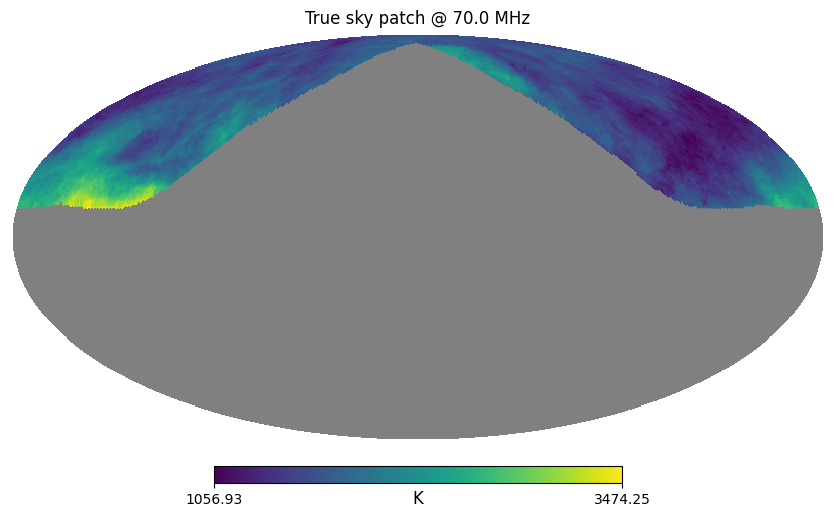

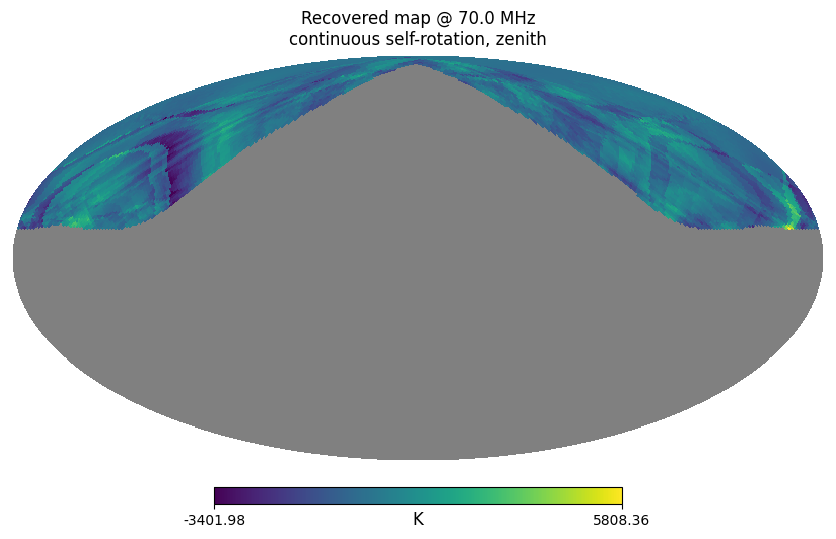

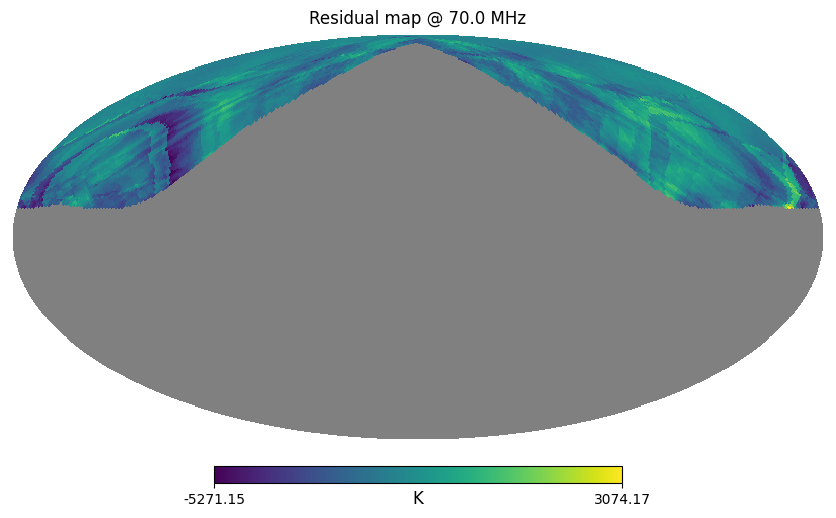

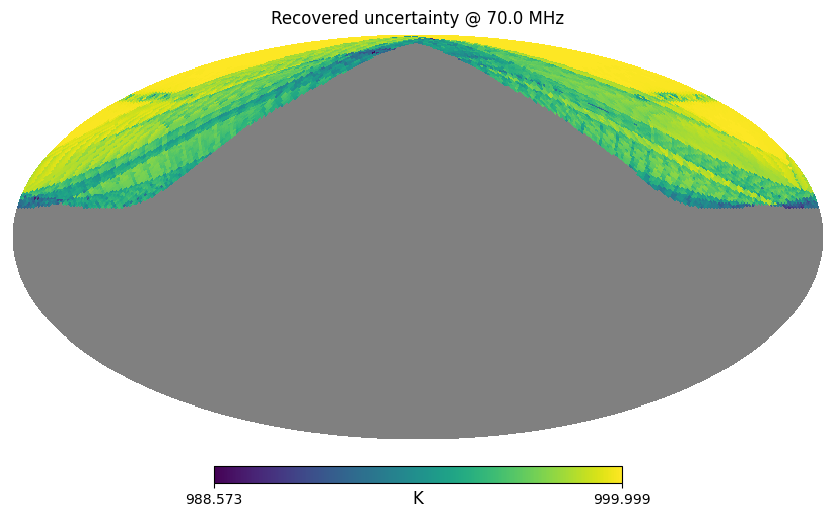

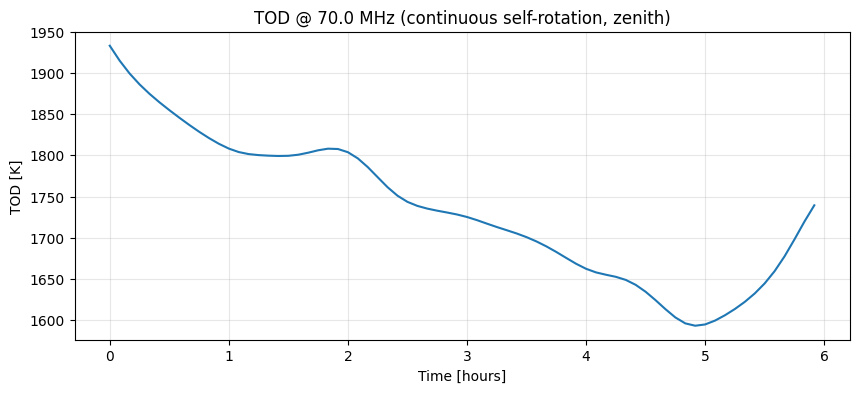

Patch RMSE: 1970.766 K
Patch bias: -1748.018 K


In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy.io import fits
import glob
import re

from limTOD import generate_LSTs_deg, generate_TOD_sky, GDSM_sky_model, HPW_mapmaking

# ============================================================
# CONFIG
# ============================================================

BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 100.0

START_TIME = "2026-04-01 20:41:56.397"

DT = 300.0                       # 5 min cadence
N_HOURS = 6
N_TIME = int((N_HOURS * 3600) / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600.0

BEAM_NSIDE = 128
SKY_NSIDE = 64
MAP_NSIDE = 64                  # target map nside for reconstruction

TARGET_FREQ = 70.0              # pick one horn-beam channel first

# continuous self rotation: 0 -> 360 over whole observation
selfrot_deg_list = (time_list / time_list[-1]) * 360.0

# zenith pointing
azimuth_deg_list = np.zeros(N_TIME)
elevation_deg_list = np.full(N_TIME, 90.0)

# ============================================================
# LOAD HORN BEAMS
# ============================================================

beam_files = sorted(glob.glob(BEAM_GLOB))
if len(beam_files) == 0:
    raise FileNotFoundError(f"No beam FITS found matching {BEAM_GLOB}")

beam_dict = {}

for f in beam_files:
    m = re.search(r"(\d+\.\d+)", f)
    if m is None:
        continue

    freq = float(m.group(1))

    with fits.open(f) as hdul:
        beam = np.array(hdul[1].data.field(0)).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0.0
    beam /= np.sum(beam)

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))
if len(freq_list) == 0:
    raise RuntimeError("No usable horn beams were loaded.")

def get_horn_beam_for_freq(freq, nside=BEAM_NSIDE):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near].copy()

    native_nside = hp.npix2nside(len(beam))
    if native_nside != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0.0

    s = np.sum(beam)
    if s <= 0:
        raise ValueError(f"Beam at {f_near} MHz has zero total weight.")
    beam /= s

    return f_near, beam

beam_freq_used, beam_map = get_horn_beam_for_freq(TARGET_FREQ, nside=BEAM_NSIDE)
print(f"Using horn beam at {beam_freq_used:.2f} MHz")

# ============================================================
# GENERATE SKY + LST
# ============================================================

LST_deg_list = generate_LSTs_deg(
    ANT_LAT,
    ANT_LON,
    ANT_H,
    time_list,
    start_time_utc=START_TIME,
)

sky_map = GDSM_sky_model(freq=beam_freq_used, nside=SKY_NSIDE)

# ============================================================
# GENERATE TOD FOR THIS SINGLE FREQUENCY CHANNEL
# ============================================================

tod = generate_TOD_sky(
    beam_map,
    sky_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

print("TOD shape:", tod.shape)

# ============================================================
# MAP MAKER SETUP
# ============================================================
# HPW_mapmaking wants:
# - beam_map: single-frequency beam map
# - LST list(s)
# - az list(s)
# - el list(s)
# - selfrot list(s)
#
# For a single TOD, these can be passed directly as arrays.
# It will internally build the sky->TOD operator using the same beam/pointing.

mapper = HPW_mapmaking(
    beam_map=beam_map,
    LST_deg_list_group=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list_group=azimuth_deg_list,
    elevation_deg_list_group=elevation_deg_list,
    selfrot_deg_list_group=selfrot_deg_list,
    threshold=0.05,
    nside_hires=BEAM_NSIDE,
    nside_target=MAP_NSIDE,
    beam_truncate_frac_thres=0.01,
)

# ============================================================
# RUN MAP MAKING
# ============================================================
# TOD_group is a single 1D TOD here
# cutoff_freq_group can be a scalar or single-element list in the single-TOD case

sky_estimation, sky_uncertainty = mapper(
    TOD_group=tod,
    dtime=DT,
    cutoff_freq_group=0.001,
    gain_group=1.0,
    regularization=1e-6,
    filter_order=4,
)

# mapper.pixel_indices gives the selected pixels used in the solve
pixel_indices = mapper.pixel_indices

print("Recovered sky parameter shape:", sky_estimation.shape)
print("Recovered uncertainty shape:", sky_uncertainty.shape)
print("Number of selected pixels:", len(pixel_indices))

# ============================================================
# PUT PATCH BACK INTO FULL HEALPIX MAP
# ============================================================

npix_target = hp.nside2npix(MAP_NSIDE)

recovered_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)
uncertainty_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)

recovered_map_full[pixel_indices] = sky_estimation
uncertainty_map_full[pixel_indices] = sky_uncertainty

# truth map at target nside for comparison
truth_map_target = hp.ud_grade(sky_map, nside_out=MAP_NSIDE)

truth_patch_full = np.full(npix_target, hp.UNSEEN, dtype=float)
truth_patch_full[pixel_indices] = truth_map_target[pixel_indices]

residual_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)
residual_map_full[pixel_indices] = sky_estimation - truth_map_target[pixel_indices]

# ============================================================
# PLOTS
# ============================================================

hp.mollview(
    truth_patch_full,
    title=f"True sky patch @ {beam_freq_used:.1f} MHz",
    unit="K"
)

hp.mollview(
    recovered_map_full,
    title=f"Recovered map @ {beam_freq_used:.1f} MHz\ncontinuous self-rotation, zenith",
    unit="K"
)

hp.mollview(
    residual_map_full,
    title=f"Residual map @ {beam_freq_used:.1f} MHz",
    unit="K"
)

hp.mollview(
    uncertainty_map_full,
    title=f"Recovered uncertainty @ {beam_freq_used:.1f} MHz",
    unit="K"
)

plt.figure(figsize=(10, 4))
plt.plot(time_hours, tod)
plt.xlabel("Time [hours]")
plt.ylabel("TOD [K]")
plt.title(f"TOD @ {beam_freq_used:.1f} MHz (continuous self-rotation, zenith)")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# SIMPLE SUMMARY METRICS ON THE SOLVED PATCH
# ============================================================

valid = pixel_indices
rmse = np.sqrt(np.mean((sky_estimation - truth_map_target[valid])**2))
bias = np.mean(sky_estimation - truth_map_target[valid])

print(f"Patch RMSE: {rmse:.3f} K")
print(f"Patch bias: {bias:.3f} K")

### BCF Corrected map making